<a href="https://colab.research.google.com/github/lakhshuyaa/data-visualization/blob/main/Dvt_Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Global YouTube Statistics.csv to Global YouTube Statistics.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [8]:
df = pd.read_csv("Global YouTube Statistics.csv", encoding='latin-1')

df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [9]:


print(df.shape)
df.info()

(995, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                        

In [10]:

print("Missing Values\n")
print(df.isnull().sum())

Missing Values

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                               

In [11]:


numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print(df.isnull().sum())


rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             0
country_rank                                 0
channel_type_rank                            0
video_views_for_the_last_30_days             0
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days                 0
created_year                                 0
created_month                                5
created_date 

In [12]:

print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 0
After Removal : (995, 28)


/tmp/ipykernel_1587/1218054281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subscribers', y='Youtuber', data=top_10_youtubers, palette='viridis')


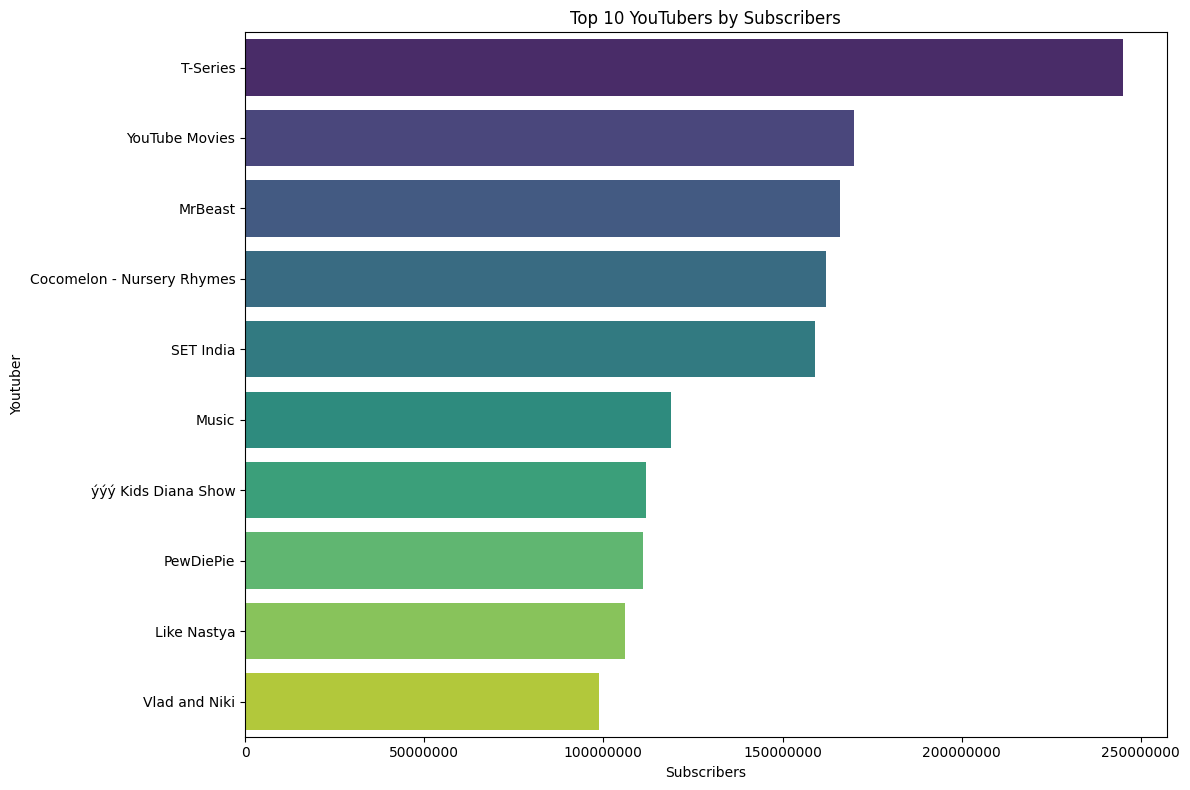

In [15]:
top_10_youtubers = df.sort_values(by='subscribers', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='subscribers', y='Youtuber', data=top_10_youtubers, palette='viridis')
plt.title('Top 10 YouTubers by Subscribers')
plt.xlabel('Subscribers')
plt.ylabel('Youtuber')
plt.ticklabel_format(style='plain', axis='x') # To prevent scientific notation on x-axis
plt.tight_layout()
plt.show()

In [16]:
display(df.describe())

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.950000e+02,995.00000,995.000000,9.950000e+02,995.000000,9.950000e+02,...,9.950000e+02,9.950000e+02,995.000000,995.000000,995.000000,9.950000e+02,995.000000,9.950000e+02,995.000000,995.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.536928e+05,346.99196,723.159296,1.693335e+08,36886.148281,5.898078e+05,...,7.081814e+06,2.985870e+05,2012.632161,15.747739,64.168241,4.177600e+08,9.289874,2.299568e+08,27.925514,-18.800556
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362209e+06,1163.09926,1915.718317,4.052958e+08,71858.724092,1.148622e+06,...,1.379704e+07,5.044333e+05,4.501215,8.755434,24.480683,4.438532e+08,4.576008,1.456064e+08,19.552101,80.313810
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.00000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.240000e+02,14.00000,28.000000,2.232300e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,40.200000,1.260140e+08,5.360000,1.026269e+08,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.00000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.579000e+03,114.00000,137.000000,1.585655e+08,37900.000000,6.068000e+05,...,7.300000e+06,2.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.00000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924
